In [982]:
%load_ext autoreload
%autoreload 2

import numpy as np
import warnings
import time

import pandas as pd
import random

import numpy.ma as ma
from tqdm import tqdm
from src.traffic_sim import *
import matplotlib.pyplot as plt

# Both me and monica load from same file
# Look at ways to fix numerical issues - bound by small epsilon (add to denominator)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [983]:
def smooth_inflow(inflow, window_size=5):
    return np.convolve(inflow, np.ones(window_size)/window_size, mode='same')

In [ ]:
# Read in the data

exp_path = '400m_10s_improved_ramping_averaged_tenth_seg'
L = 0.4
total_time = 1
time_step = 10/3600
start_time = 0

density_data = np.load(f'src/sim_params/gt_i24_data/AveragedExtraSegment/density_{int(time_step * 3600)}sec_{int(L * 1000)}m_{total_time}hr.npy')
velocity_data = np.load(f'src/sim_params/gt_i24_data/AveragedExtraSegment/velocity_{int(time_step * 3600)}sec_{int(L * 1000)}m_{total_time}hr.npy')
print(density_data.shape)

true_density_initial = density_data[start_time, 1:-1].reshape(-1)
true_velocity_initial = velocity_data[start_time, 1:-1].reshape(-1)

density_path =  'old/400m_10s_joint'
get_from_gt = True

if get_from_gt:
    downstream_density = density_data[0:, -1].reshape(-1)
    data_inflow = (velocity_data[0:, 0] * density_data[0:, 0]).reshape(-1)
else:
    try:
        downstream_density = np.load(f'src/sim_params/{exp_path}/downstream_density.npy').reshape(-1)
        data_inflow = np.load(f'src/sim_params/{exp_path}/upstream_flow.npy').reshape(-1)
    except:
        downstream_density = np.load(f'src/sim_params/{density_path}/downstream_density.npy').reshape(-1)
        data_inflow = np.load(f'src/sim_params/{density_path}/upstream_flow.npy').reshape(-1)

data_inflow = smooth_inflow(data_inflow, window_size=2)
downstream_density = smooth_inflow(downstream_density, window_size=2)

# Predicted from calibration optimization
v_pred = np.load(f'src/sim_params/{exp_path}/v_pred.npy')[start_time:, :]
rho_pred = np.load(f'src/sim_params/{exp_path}/rho_pred.npy')[start_time:, :]


if exp_path == '400m_30s_metanet_10s' and not get_from_gt:
    downstream_density = np.repeat(downstream_density, 3, axis=0)
    data_inflow = np.repeat(data_inflow, 3, axis=0)

    downstream_density = smooth_inflow(downstream_density, window_size=2)
    data_inflow = smooth_inflow(data_inflow, window_size=2)

print("time steps:", downstream_density.shape)
print("num segments:", true_density_initial.shape)
print(v_pred.shape)
print(true_velocity_initial)
print(v_pred[0, :])


(360, 16)
time steps: (359,)
num segments: (14,)
(360, 14)
[15.60562109 22.63969379 14.53123911 33.0528382  44.74894381 40.31822336
 36.43426698 50.4408325  24.55019846 16.80160164  5.34702448 21.88636564
 40.55200066 44.41112619]
[15.60562109 22.63969379 14.53123911 33.0528382  44.74894381 40.31822336
 36.43426698 50.4408325  24.55019846 16.80160164  5.34702448 21.88636564
 40.55200066 44.41112619]


initial density: [40.729997   32.2199985  45.21999775 33.459998   28.129998   30.10999863
 32.08999925 18.6499975  38.44999875 32.22999875 26.00999875 38.2799965
 31.5699985  38.299997  ]
[40.729997   32.2199985  45.21999775 33.459998   28.129998   30.10999863
 32.08999925 18.6499975  38.44999875 29.949999   26.00999875 38.2799965
 31.5699985  38.299997  ]


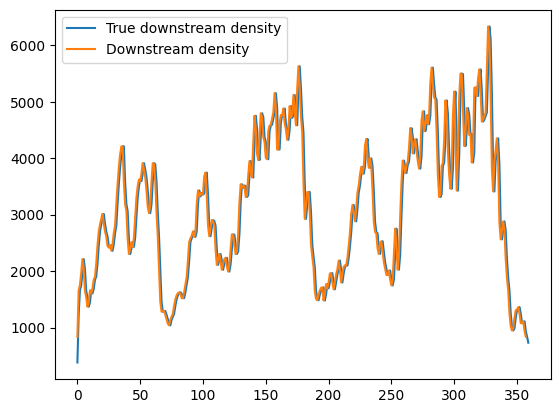

In [1002]:
density_data_other = np.load(f'src/sim_params/gt_i24_data/density_{int(time_step * 3600)}sec_{int(L * 1000)}m_{1}hr.npy')[0:360, :]
velocity_data_other = np.load(f'src/sim_params/gt_i24_data/velocity_{int(time_step * 3600)}sec_{int(L * 1000)}m_{1}hr.npy')[0:360, :]
plt.plot(smooth_inflow(density_data_other[:, 0] * velocity_data_other[:, 0], window_size=2), label='True downstream density')
plt.plot(data_inflow[0:-1], label='Downstream density')
plt.legend()

print("initial density:", true_density_initial)
print(density_data_other[start_time, 1:-1])

In [1003]:
from src.sim_params.default import DefaultParams
from src.sim_params.I24_400mParams import I24_400mParams
from src.sim_params.I24_6seg_FD_400mParams import I24_400m_6seg_indivFD_Params
from src.sim_params.I24_14seg_200mParams import I24_200m_14seg_indivFD_Params
from src.sim_params.I24_30seg_200mParams import I24_30seg_200m_indivFD_Params

In [1004]:
time_steps = downstream_density.shape[0]
print("sim_time:", time_step * downstream_density.shape[0] * 60, "minutes")
num_segments = 14 #30
total_distance = L * num_segments # km
try:
    lane_counts = np.load(f'src/sim_params/{exp_path}/lane_num.npy').reshape(-1)
except:
    lane_counts = np.load(f'src/sim_params/{exp_path}/num_lanes.npy').reshape(-1)
#lane_counts = np.load('src/sim_params/200m_10_sec/lane_num.npy').reshape(-1)
# lane_counts = smooth_inflow(lane_counts, window_size=3)
sim_lanes = {i: lane_counts[i] for i in range(num_segments)}
#sim_lanes = {i: 4 for i in range(num_segments)}
print("length of highway:", total_distance, "km")
print(sim_lanes)
downstream_density = downstream_density / sim_lanes[num_segments - 1]
i24params = I24_30seg_200m_indivFD_Params(path=exp_path).get_params()
#i24params = DefaultParams(num_segments=num_segments).get_params()
print(i24params.keys())
print(i24params['beta'].shape)



# print(data_inflow.shape, lane_counts.shape)

# inflow = np.full(data_inflow.shape, 1000 * 4)


sim_time: 59.833333333333336 minutes
length of highway: 5.6000000000000005 km
{0: 3.06479559432833, 1: 4.520018797892743, 2: 2.9999999706849416, 3: 5.000000047058109, 4: 3.0459271296593795, 5: 4.764453449311267, 6: 3.7313825732455532, 7: 4.45020715323498, 8: 2.999999970307758, 9: 3.364698971398251, 10: 4.353831335912919, 11: 5.000000049672633, 12: 2.999999972256811, 13: 2.9999999705333438}
dict_keys(['tau', 'K', 'eta_high', 'p_crit', 'v_free', 'a', 'q_capacity', 'r', 'beta', 'gamma'])
(14,)


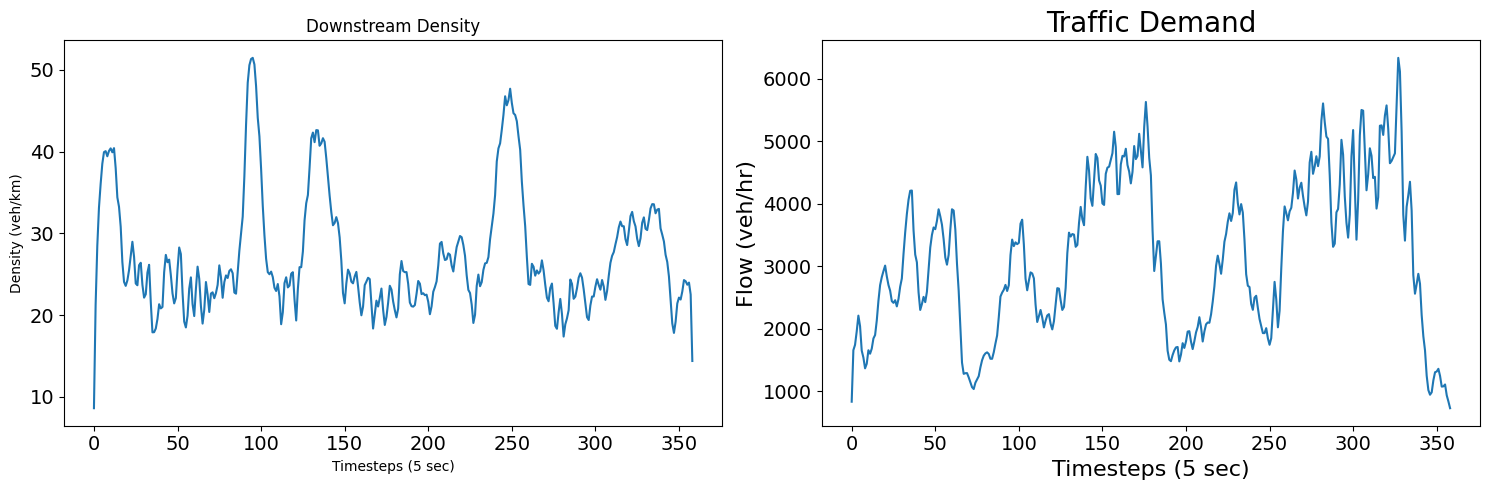

In [1005]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(downstream_density)
axs[0].set_title('Downstream Density')
# axs[0].set_xticks(np.arange(0, time_steps+1, 120), np.arange(0, int(time_steps/12)+1, int(120/12)))
axs[0].set_xlabel('Timesteps (5 sec)')
axs[0].set_ylabel('Density (veh/km)')

axs[1].plot(data_inflow)
axs[1].set_title('Traffic Demand', fontsize=20)
# axs[1].set_xticks(np.arange(0, time_steps+1, 120), np.arange(0, int(time_steps/12)+1, int(120/12)))
axs[1].set_xlabel('Timesteps (5 sec)', fontsize=16)
axs[1].set_ylabel('Flow (veh/hr)', fontsize=16)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

In [1006]:
#{i: 4 if i < int(2*num_segments/3) else 2 for i in range(num_segments)}
const_vsl = np.array([np.full(num_segments, max(i24params['v_free'])) for i in range(time_steps)])
# p, v, queue, tts = metanet_sim_params(time_step, L, 
#                                       (np.array([inflow[0]/(i24params['v_free'] * sim_lanes[i]) for i in range(num_segments)]), np.full(num_segments, i24params['v_free']), inflow[0], 0), 
#                                     const_vsl, inflow, downstream_density, params=i24params, plotting=True, real_data=True, lanes=sim_lanes)

# print(v.shape)
print(i24params['p_crit'])
for k in i24params.keys():
    print(k, i24params[k][9])

print(i24params['K'])

# if start_time == 0:
#   true_density_init_norm = np.array([true_density_initial[i] / sim_lanes[i] for i in range(num_segments)])
#   init_state = (true_density_init_norm, true_velocity_initial, data_inflow[start_time], 0)
# else:
# true_density_init_norm = np.array([rho_pred[0, i] / sim_lanes[i] for i in range(num_segments)])
# init_state = (true_density_init_norm, v_pred[0, :], data_inflow[start_time], 0)

if start_time == 0:
    true_density_init_norm = np.array([true_density_initial[i] / sim_lanes[i]
                                       for i in range(num_segments)])
    init_state = (true_density_init_norm,
                  true_velocity_initial,
                  data_inflow[0],  # inflow at t=0
                  0)
else:
    true_density_init_norm = np.array([rho_pred[0, i] / sim_lanes[i]
                                       for i in range(num_segments)])
    init_state = (true_density_init_norm,
                  v_pred[0, :],
                  data_inflow[start_time],
                  0)


print(num_segments, time_steps)
p, v, queue, tts = metanet_sim_params(time_step, L, init_state, 
                                    const_vsl[start_time:, :], data_inflow[start_time:], downstream_density[start_time:], params=i24params, plotting=True, real_data=True,
                                      lanes=sim_lanes, upstream_velocity=None)

print("Total travel time:", tts)
print(p.shape, v.shape)


[23.372418173154852, 23.933681213003553, 10.976351553253272, 13.741665384761516, 14.795307605884181, 41.52210616454495, 22.83821567503395, 24.55287507074126, 26.09921178821557, 4.299556195519616, 22.414748214354034, 22.68624254395033, 28.553683202733, 25.665541707000017]
tau 0.016666676664883147
K 0.9999999944092254
eta_high 79.64747518579183
p_crit 4.299556195519616
v_free 101.29579865981057
a 6.29173391883567
q_capacity 2200
r 1130.3085992397932
beta 0.29192548958006737
gamma 1
[0.9999999932196719, 0.9999999924731184, 1.0000000152547603, 0.9999999911799606, 0.9999999915322973, 0.9999999976684554, 0.9999999917450291, 3.3626546328431477, 0.9999999912200975, 0.9999999944092254, 50.00000041755159, 0.9999999944379105, 0.9999999920589353, 42.51588625240549]
14 359
Total travel time: 1344.0022851951442
(360, 14) (360, 14)


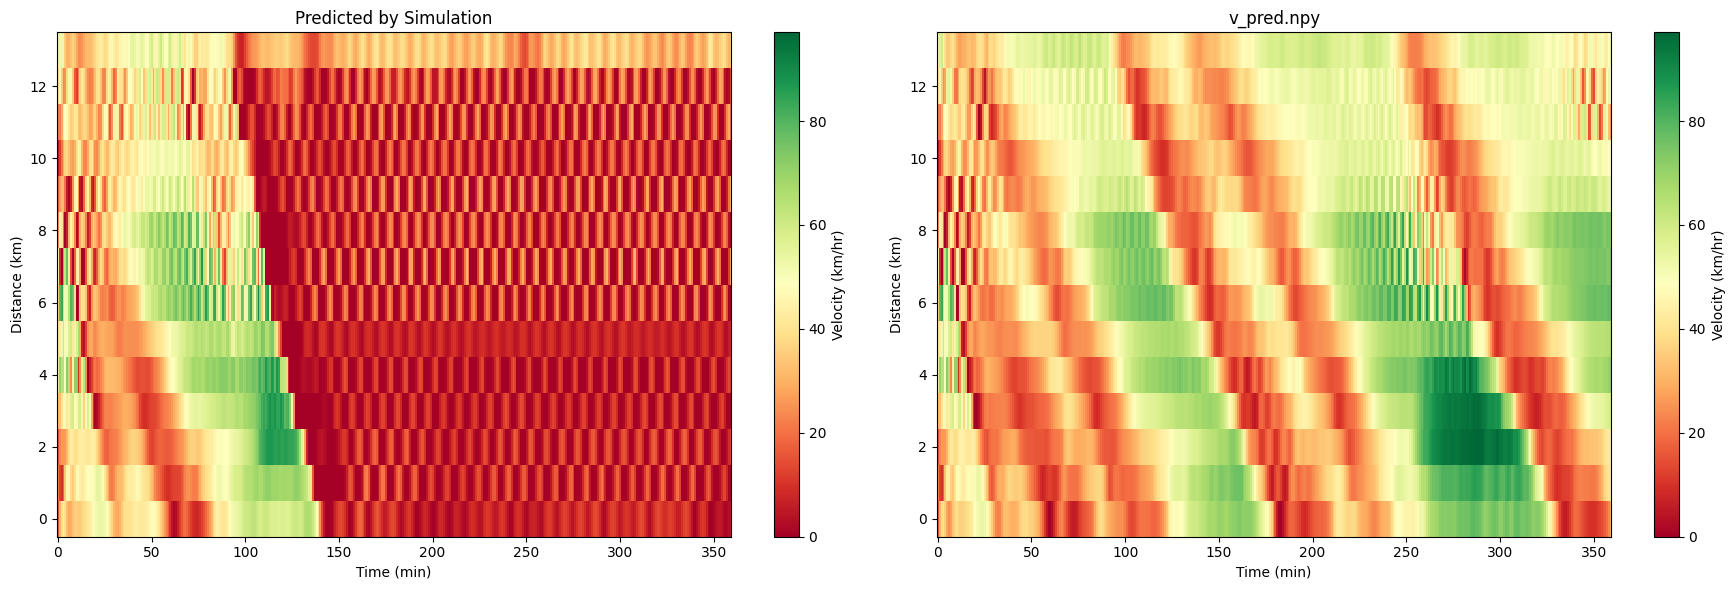

In [1007]:
# Read in v_pred.npy from the path location
max_v = max(np.max(v_pred), np.max(v))
plt.figure(figsize=(18, 6))

# Plot current v heatmap
plt.subplot(1, 2, 1)
plt.imshow(v.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v)
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.title('Predicted by Simulation')

# Plot v_pred heatmap
plt.subplot(1, 2, 2)
plt.imshow(v_pred.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v)
plt.xlabel('Time (min)')
plt.ylabel('Distance (km)')
plt.colorbar(label='Velocity (km/hr)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('bottom')
plt.title('v_pred.npy')

plt.tight_layout()
plt.show()

In [991]:
from src.traffic_sim import calculate_V, velocity_dynamics_MN, density_dynamics
print(rho_pred[start_time, :]/lane_counts)
print(p[0, :])
# def calculate_V(rho, v_ctrl, a, p_crit, v_free):
#     return min(v_free * np.exp(-1/a * (rho / p_crit)**a), v_ctrl)

# V = calculate_V(p[0,0], const_vsl[0,0], i24params['a'][0], i24params['p_crit'][0], i24params['v_free'][0])

# v_1_0 = v[0, 0] + time_step/i24params['tau'][0] * (V - v[0, 0]) - (i24params['eta_high'][0] * time_step * (p[0, 1] - p[0,0])) / (i24params['tau'][0] * L * (p[0,0] + i24params['K'][0]))
# # print(time_step/i24params['tau'][0] * (V - v[0, 0]))
# # print((i24params['eta_high'][0] * time_step * (p[0, 1] - p[0,0])) / (i24params['tau'][0] * L * (p[0,0] + i24params['K'][0])))
# print(v_1_0)

# for seg_num in range(num_segments):
#     v_sim = v[0:-1, seg_num]
#     v_calib = v_pred[start_time:, seg_num]
#     for i in range(len(v_sim)):
#         if abs(v_sim[i] - v_calib[i]) > 0.001:
#             print(i, seg_num, v_sim[i], v_calib[i])
#             # print(p[i, seg_num], rho_pred[i, seg_num])
#             ind=i
#             break

# ind = 310


seg_num = 7
ind = 0
lanes = sim_lanes[seg_num]
print(i24params['beta'][seg_num], i24params['r'][seg_num])
if seg_num == 0:
    p_next_sim = density_dynamics(p[ind, seg_num], data_inflow[ind], (v[ind, seg_num] * p[ind, seg_num] * lanes), lanes, time_step, L, gamma=i24params['gamma'][seg_num], beta=i24params['beta'][seg_num], r=i24params['r'][seg_num]) #v[ind, seg_num-1] * p[ind, seg_num-1] * 4
    p_next_calib = density_dynamics(rho_pred[ind, seg_num]/lanes, data_inflow[ind], v_pred[ind, seg_num] * rho_pred[ind, seg_num], lanes, time_step, L, gamma=i24params['gamma'][seg_num], beta=i24params['beta'][seg_num], r=i24params['r'][seg_num])

else:
    p_next_sim = density_dynamics(p[ind, seg_num], v[ind, seg_num-1] * p[ind, seg_num-1] * sim_lanes[seg_num-1], v[ind, seg_num] * p[ind, seg_num] * lanes, lanes, time_step, L, gamma=i24params['gamma'][seg_num], beta=i24params['beta'][seg_num], r=i24params['r'][seg_num]) #v[ind, seg_num-1] * p[ind, seg_num-1] * 4
    p_next_calib = density_dynamics(rho_pred[ind, seg_num]/lanes, v_pred[ind, seg_num-1] * rho_pred[ind, seg_num-1], v_pred[ind, seg_num] * rho_pred[ind, seg_num], lanes, time_step, L, gamma=i24params['gamma'][seg_num], beta=i24params['beta'][seg_num], r=i24params['r'][seg_num])

# print("------- TEST-------")
# print("inflow", v[ind, seg_num-1] * p[ind, seg_num-1] * lanes)
# print("outflow", v[ind, seg_num] * p[ind, seg_num] * lanes)
# print("current", p[ind, seg_num])
# print("lanes", lanes)
# print(p[ind, seg_num] + time_step * (v[ind, seg_num-1] * p[ind, seg_num-1] * lanes - v[ind, seg_num] * p[ind, seg_num] * lanes) / (L* lanes))
# print("-------------------")

print("---- DENSITY TEST ----")
print(p_next_sim, p[ind+1, seg_num])
print(f"Predicted value from calibration: {rho_pred[ind+1, seg_num]/lanes}")
print(f"Expected value based on METANET density equation: {p_next_calib}")

if seg_num == num_segments - 1:
    v_next_sim = velocity_dynamics_MN(v[ind, seg_num], v[ind, seg_num-1], p[ind, seg_num], downstream_density[ind], const_vsl[ind, seg_num], time_step, L,
                                eta_high=i24params['eta_high'][seg_num], K=i24params['K'][seg_num], tau=i24params['tau'][seg_num], a=i24params['a'][seg_num], p_crit=i24params['p_crit'][seg_num], v_free=i24params['v_free'][seg_num])

    v_next_calib = velocity_dynamics_MN(v_pred[ind, seg_num], v_pred[ind, seg_num-1], rho_pred[ind, seg_num], downstream_density[ind], const_vsl[ind, seg_num], time_step, L,
                                eta_high=i24params['eta_high'][seg_num], K=i24params['K'][seg_num], tau=i24params['tau'][seg_num], a=i24params['a'][seg_num], p_crit=i24params['p_crit'][seg_num], v_free=i24params['v_free'][seg_num])
else:
    v_next_sim = velocity_dynamics_MN(v[ind, seg_num], v[ind, seg_num-1], p[ind, seg_num], p[ind, seg_num+1], const_vsl[ind, seg_num], time_step, L,
                                eta_high=i24params['eta_high'][seg_num], K=i24params['K'][seg_num], tau=i24params['tau'][seg_num], a=i24params['a'][seg_num], p_crit=i24params['p_crit'][seg_num], v_free=i24params['v_free'][seg_num])

    v_next_calib = velocity_dynamics_MN(v_pred[ind, seg_num], v_pred[ind, seg_num-1], rho_pred[ind, seg_num]/sim_lanes[seg_num], rho_pred[ind, seg_num+1]/sim_lanes[seg_num+1], const_vsl[ind, seg_num], time_step, L,
                                eta_high=i24params['eta_high'][seg_num], K=i24params['K'][seg_num], tau=i24params['tau'][seg_num], a=i24params['a'][seg_num], p_crit=i24params['p_crit'][seg_num], v_free=i24params['v_free'][seg_num])

    print(v[ind, seg_num], v_pred[ind, seg_num])
    print(v[ind, seg_num-1], v_pred[ind, seg_num-1])
    print(p[ind, seg_num], rho_pred[ind, seg_num]/lanes)
    print(p[ind, seg_num+1], rho_pred[ind, seg_num+1]/sim_lanes[seg_num+1])

print("---- VELOCITY TEST ----")
print(v_next_sim, v[ind+1, seg_num])
print(f"Predicted value from calibration: {v_pred[ind+1, seg_num]}")
print(f"Expected value based on METANET velocity equation: {v_next_calib}")

print(rho_pred[ind, seg_num])
print((rho_pred[ind, seg_num]/lanes) * lanes)
# First segment
# 10th segment (index 9)
# print(gt[0,:])
#15.605621085608123

[11.93854754 12.69565346 17.12880814  9.44186447  4.17864283 11.62047314
  9.2839149  12.39714659  7.94677068 14.83389782 13.32685389  8.92591723
  7.91479672 17.56631135]
[12.37142077  9.34845228 17.91811996  7.85987757  7.86859287  9.17993643
 11.33633604  6.03371371 12.38500059 12.2815417   9.68169403  8.07040544
  9.13383263 16.41846673]
0.03408031709023473 985.7211448765473
---- DENSITY TEST ----
12.397146586850976 12.397146586850976
Predicted value from calibration: 12.397146586850974
Expected value based on METANET density equation: 12.397146586850976
8.611436301330455 8.611436301330455
78.75949402195303 78.75949402195303
6.033713712236233 6.033713712236233
12.385000592263212 12.385000592263212
---- VELOCITY TEST ----
0.0009999947471186488 0.0009999947471186488
Predicted value from calibration: 0.0009999947471223379
Expected value based on METANET velocity equation: 0.0009999947471186488
26.851275922765673
26.85127592276567


In [967]:
gt = np.load(f'src/sim_params/gt_i24_data/velocity_{int(time_step * 3600)}sec_{int(L * 1000)}m_{total_time}hr.npy')[:, 1:num_segments+1]
gt_density = np.load(f'src/sim_params/gt_i24_data/density_{int(time_step * 3600)}sec_{int(L * 1000)}m_{total_time}hr.npy')[:, 1:num_segments+1]
gt_flow = gt * gt_density

# check if rho_pred has negative values
print("Min density in calibration:", np.max(rho_pred))
print("Min velocity in calibration:", np.max(gt_density)*4.5)

gt_density_norm = gt_density / lane_counts[0:num_segments]

vel = v[:-1, :]
density = p[:-1, :]
flow = vel * density * lane_counts[0:num_segments]

mape = np.mean(np.abs((gt - vel) / gt) * 100)
p_mape = np.mean(np.abs((gt_density - density * lane_counts) / gt_density) * 100)
q_mape = np.mean(np.abs((gt_flow - flow) / gt_flow) * 100)
print("Density MAPE:", np.round(p_mape, 2), "%")
print("Velocity MAPE:", np.round(mape, 2), "%")
print("Flow MAPE:", np.round(q_mape, 2), "%")

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
""
rmse_value = rmse(gt, vel)
p_rmse_value = rmse(gt_density_norm, density)
q_rmse = rmse(gt_flow, flow)
print("Density RMSE:", np.round(p_rmse_value, 2))
print("Velocity RMSE:", rmse_value)
print("Flow RMSE:", np.round(q_rmse, 2))

Min density in calibration: 239.59080827778692
Min velocity in calibration: 1012.8149831250012


ValueError: operands could not be broadcast together with shapes (360,14) (359,14) 

In [956]:
# Travel time of gt
gt_tt = time_step * (sum([np.sum(gt_density[:, i]) * sim_lanes[i] * L for i in range(num_segments)]))
metanet_tt = time_step * (sum([np.sum(density[:, i]) * sim_lanes[i] * L for i in range(num_segments)]))
print("Ground Truth Travel Time:", np.round(gt_tt, 2), "veh-hr")
print("Metanet Travel Time:", np.round(metanet_tt, 2), "veh-hr")

Ground Truth Travel Time: 2152.93 veh-hr
Metanet Travel Time: 473.47 veh-hr


Error on TTS:
78.00809107666343 %


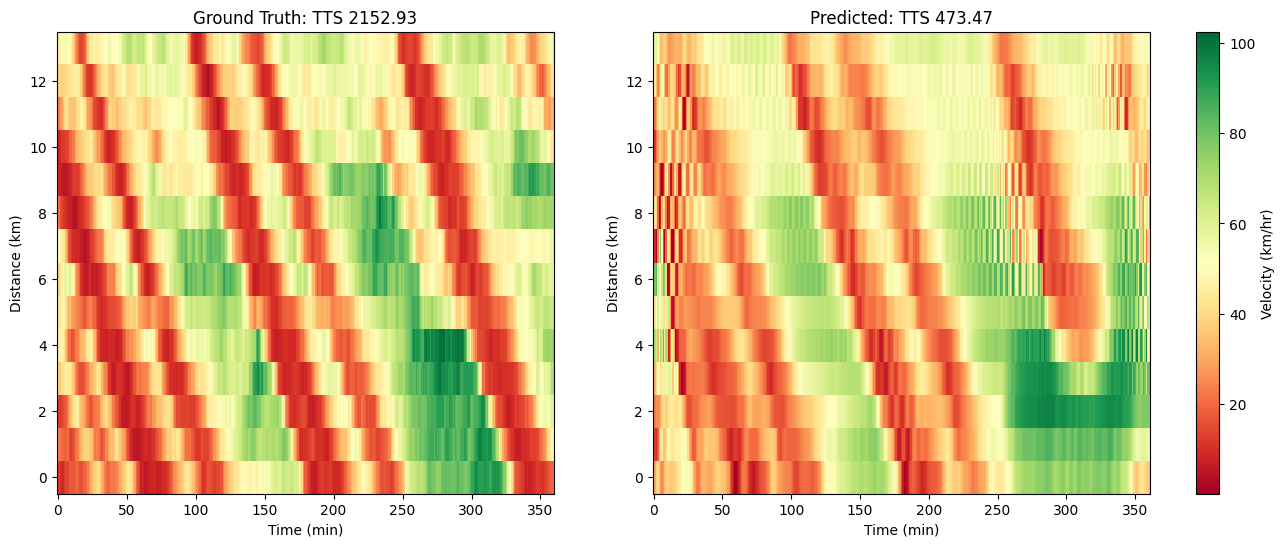

In [957]:
import matplotlib.colors as mcolors
# print error on tts
print("Error on TTS:")
print(abs(gt_tt - metanet_tt)/gt_tt * 100, "%")

# Normalize the color scale
vmin = min(gt.min(), v.min())
vmax = max(gt.max(), v.max())
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Plot gt
im1 = axs[0].imshow(gt.T, cmap='RdYlGn', aspect='auto', norm=norm, interpolation='none')
axs[0].set_title(f'Ground Truth: TTS {np.round(gt_tt, 2)}')
axs[0].set_xlabel('Time (min)')
axs[0].set_ylabel('Distance (km)')
axs[0].invert_yaxis()
axs[0].xaxis.set_ticks_position('bottom')

# Plot v
im2 = axs[1].imshow(v.T, cmap='RdYlGn', aspect='auto', norm=norm, interpolation='none')
axs[1].set_title(f'Predicted: TTS {np.round(metanet_tt, 2)}')
axs[1].set_xlabel('Time (min)')
axs[1].set_ylabel('Distance (km)')
axs[1].invert_yaxis()
axs[1].xaxis.set_ticks_position('bottom')

# Add a single color bar for both plots
cbar = fig.colorbar(im1, ax=axs, orientation='vertical', fraction=0.02, pad=0.04, label='Velocity (km/hr)')

# plt.tight_layout()
plt.show()

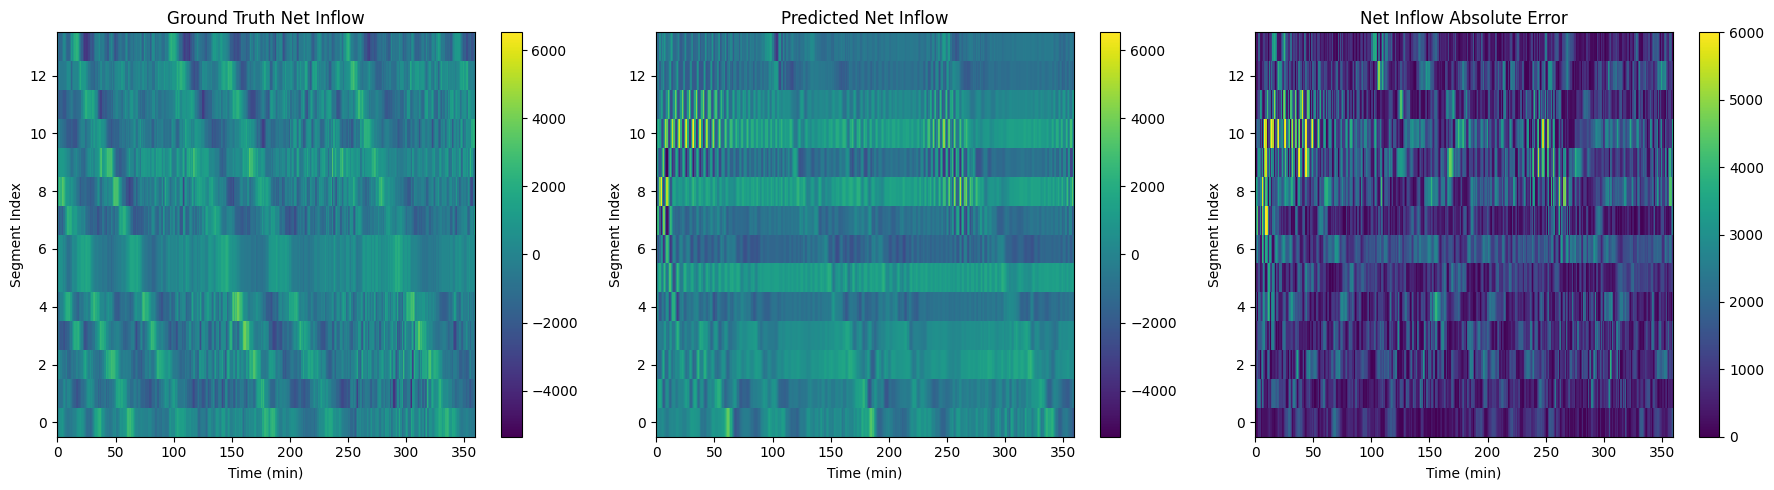

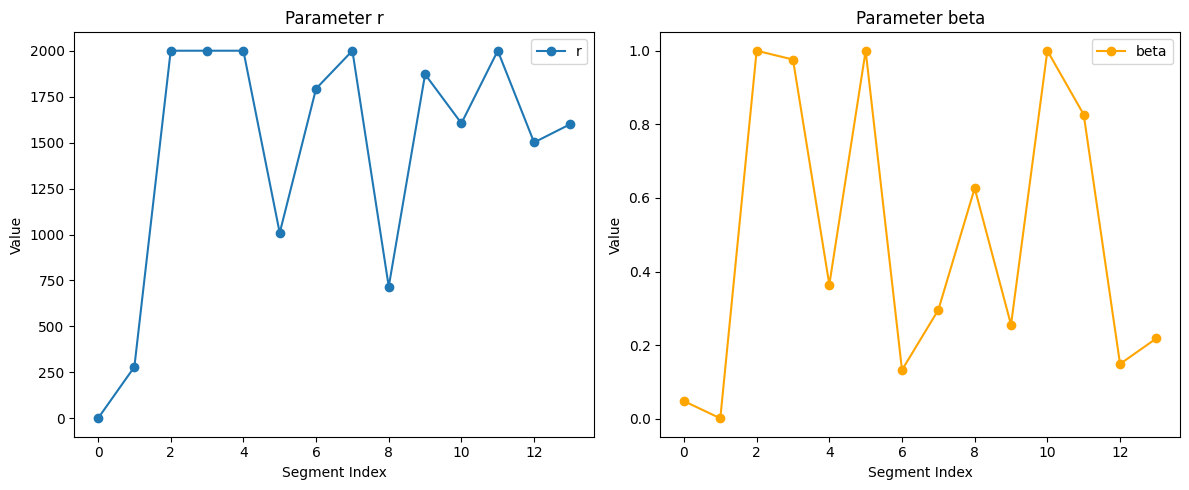

In [488]:
def get_velocity_heatmap(v_hat, v_pred, q_hat, q_pred, rho_hat, rho_pred):
    shortened_v_hat = v_hat
    shortened_rho_hat = rho_hat
    shortened_q_hat = q_hat
    # Determine some set of 3 scalars for each of q, rho, v to make a unified map
    v_diff = np.abs(shortened_v_hat - v_pred)/shortened_v_hat
    rho_diff = np.abs(shortened_rho_hat - rho_pred)/shortened_rho_hat 
    q_diff = np.abs(shortened_q_hat - q_pred)/shortened_q_hat

    diff = v_diff + rho_diff
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    im = ax1.imshow(diff.T, aspect='auto', origin='lower',
                cmap='viridis', interpolation="none", vmin=0, vmax=1)
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Segment Index')
    ax1.set_title('Combined Normalized Difference Heatmap')
    fig.colorbar(im, ax=ax1)

    im2 = ax2.imshow(shortened_v_hat.T, aspect='auto', origin='lower',
                    cmap='RdYlGn', interpolation="none")
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Segment Index')
    ax2.set_title('Ground Truth Velocity Heatmap')
    fig.colorbar(im2, ax=ax2, label='Velocity (km/hr)')

    plt.tight_layout()
    plt.show()

# Calculate the error on the net_inflow
def get_net_inflow_error(q_hat, q_pred, highway_inflow):
    # Calculate net inflow for each segment and time
    q_hat_inflow = np.hstack((highway_inflow.reshape(-1, 1), q_hat))[:, :-1]
    q_pred_inflow = np.hstack((highway_inflow.reshape(-1, 1), q_pred))[:, :-1]
    net_inflow_hat = q_hat_inflow - q_hat
    net_inflow_pred = q_pred_inflow - q_pred
    mape = np.abs(net_inflow_hat - net_inflow_pred)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    netinflow_min = min(net_inflow_hat.min(), net_inflow_pred.min())
    netinflow_max = max(net_inflow_hat.max(), net_inflow_pred.max())

    im0 = axs[0].imshow(net_inflow_hat.T, cmap='viridis', aspect='auto', interpolation='none', vmin=netinflow_min, vmax=netinflow_max)
    axs[0].set_title('Ground Truth Net Inflow')
    axs[0].set_xlabel('Time (min)')
    axs[0].set_ylabel('Segment Index')
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(net_inflow_pred.T, cmap='viridis', aspect='auto', interpolation='none', vmin=netinflow_min, vmax=netinflow_max)
    axs[1].set_title('Predicted Net Inflow')
    axs[1].set_xlabel('Time (min)')
    axs[1].set_ylabel('Segment Index')
    plt.colorbar(im1, ax=axs[1])

    im2 = axs[2].imshow(mape.T, cmap='viridis', aspect='auto', interpolation='none', vmax=6000)
    axs[2].set_title('Net Inflow Absolute Error')
    axs[2].set_xlabel('Time (min)')
    axs[2].set_ylabel('Segment Index')
    plt.colorbar(im2, ax=axs[2])

    for ax in axs:
        ax.invert_yaxis()
        ax.xaxis.set_ticks_position('bottom')

    plt.tight_layout()
    plt.show()
    


#get_velocity_heatmap(gt, vel, gt * gt_density, flow, gt_density, density)

get_net_inflow_error(gt_flow, flow, data_inflow)

# plot r and beta
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(i24params['r'], marker='o', label='r')
axs[0].set_xlabel('Segment Index')
axs[0].set_ylabel('Value')
axs[0].set_title('Parameter r')
axs[0].legend()

axs[1].plot(i24params['beta'], marker='o', label='beta', color='orange')
axs[1].set_xlabel('Segment Index')
axs[1].set_ylabel('Value')
axs[1].set_title('Parameter beta')
axs[1].legend()

plt.tight_layout()
plt.show()

In [89]:
pred_horizon = 50  # 30 minutes
control_horizon = 5  # 10 minutes
hold_len = 1

sim_time = downstream_density.shape[0]
time_steps = sim_time + pred_horizon - control_horizon
downstream_density_mpc = np.append(downstream_density, downstream_density[-1])
inflow_mpc = np.append(data_inflow, data_inflow[-1])
while len(downstream_density_mpc) <= time_steps + 1:
    downstream_density_mpc = np.append(downstream_density_mpc, downstream_density[-1])
    inflow_mpc = np.append(inflow_mpc, data_inflow[-1])

print(data_inflow.shape, downstream_density.shape)
print(downstream_density_mpc.shape, inflow_mpc.shape, time_steps)

(360,) (360,)
(407,) (407,) 405


In [90]:
# Optimize I-24 Scenario
from src.mpc_metanet import mpc_find_vsl

m = num_segments

optimal_vsl = mpc_find_vsl(time_steps, inflow_mpc, downstream_density_mpc, sim_lanes, T=time_step,
                                l=L, num_segments=num_segments, pred_horizon=pred_horizon, control_horizon=control_horizon, 
                                hold_length=hold_len, initialize_vsl=None, init_fixed=None, init_state=init_state,
                                control_one_segment=None, control_changepoints=None, safety_temporal=1, params=i24params, verbose=True, speed_lb=0)

print(optimal_vsl.shape)

MPC at time step 0
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.16\x3a Converged to a locally infeasible
      point. Problem may be infeasible.
Infeasible
MPC at time step 50
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.16\x3a Converged to a locally infeasible
      point. Problem may be infeasible.
Infeasible
MPC at time step 100
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.16\x3a Converged to a locally infeasible
      point. Problem may be infeasible.
Infeasible
MPC at time step 150
MPC at time step 200
MPC at time step 250
MPC at time step 300
MPC at time step 350
MPC Done
(360, 14)


In [104]:
print(const_vsl.shape, optimal_vsl.shape)
p_opt, v_opt, queue_opt, tts_opt = metanet_sim_params(time_step, L, init_state, 
                                    const_vsl, inflow_mpc, downstream_density_mpc, i24params, lanes=sim_lanes, real_data=False, plotting=True)

#save optimal_vsl
np.save(f'src/sim_params/{path}/optimal_vsl_smooth.npy', optimal_vsl)
print(f"TTS with VSL Control: {tts_opt} veh-hr")
print(f"TTS without VSL Control: {tts} veh-hr")

(360, 14) (360, 14)
TTS with VSL Control: 291.54504271322503 veh-hr
TTS without VSL Control: 482.08882780687316 veh-hr


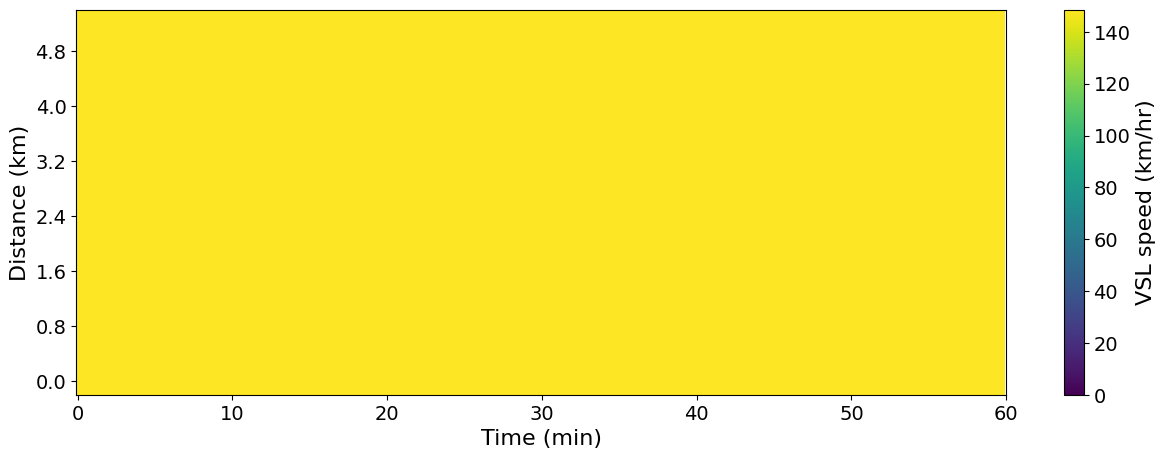

In [105]:
from src.plotting import plot_vsls
plot_vsls(const_vsl, time_steps, num_segments, max(i24params['v_free']), T=time_step, l=L)

In [109]:
print(np.max(data_inflow)/sim_lanes[0])
print(np.max(gt_density/lane_counts))

1637.8053415130398
65.63666681581186


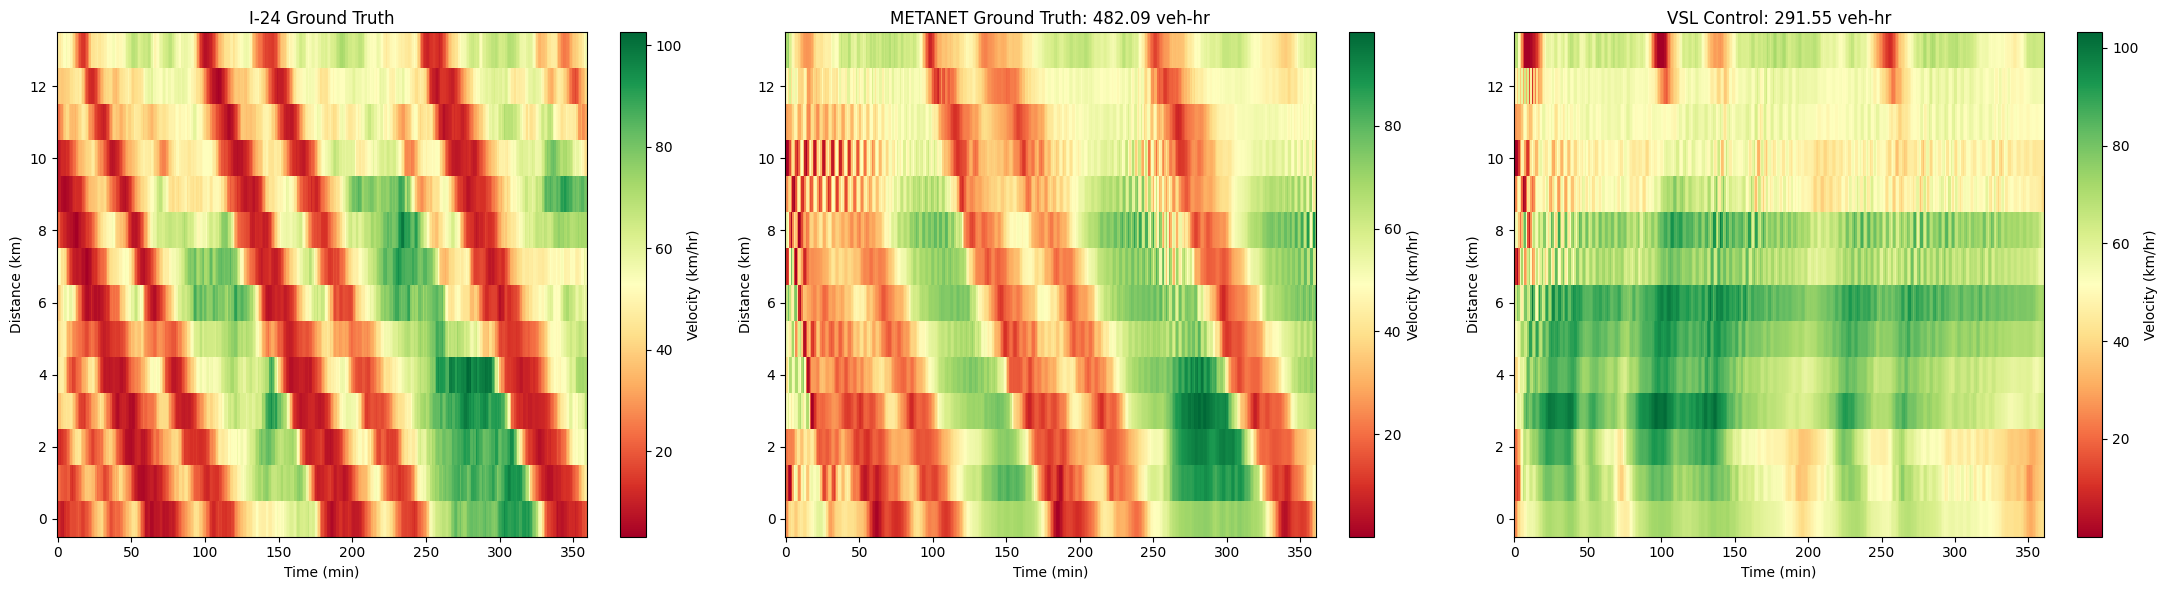

In [106]:
fig, axs = plt.subplots(1, 3, figsize=(22, 6))

# Plot ground truth (I-24)
im0 = axs[0].imshow(gt.T, cmap='RdYlGn', aspect='auto', interpolation='none')
axs[0].set_title('I-24 Ground Truth')
axs[0].set_xlabel('Time (min)')
axs[0].set_ylabel('Distance (km)')
axs[0].invert_yaxis()
axs[0].xaxis.set_ticks_position('bottom')
fig.colorbar(im0, ax=axs[0], label='Velocity (km/hr)')

# Plot METANET ground truth
im1 = axs[1].imshow(v.T, cmap='RdYlGn', aspect='auto', interpolation='none')
axs[1].set_title('METANET Ground Truth: ' + str(np.round(tts, 2)) + ' veh-hr')
axs[1].set_xlabel('Time (min)')
axs[1].set_ylabel('Distance (km)')
axs[1].invert_yaxis()
axs[1].xaxis.set_ticks_position('bottom')
fig.colorbar(im1, ax=axs[1], label='Velocity (km/hr)')

# Plot METANET with control
im2 = axs[2].imshow(v_opt.T, cmap='RdYlGn', aspect='auto', interpolation='none')
axs[2].set_title('VSL Control: ' + str(np.round(tts_opt, 2)) + ' veh-hr')
axs[2].set_xlabel('Time (min)')
axs[2].set_ylabel('Distance (km)')
axs[2].invert_yaxis()
axs[2].xaxis.set_ticks_position('bottom')
fig.colorbar(im2, ax=axs[2], label='Velocity (km/hr)')

plt.tight_layout()
plt.show()

In [35]:
from generate_demand import get_ff_tt

ff_ttt = get_ff_tt(data_inflow, time_step, L * num_segments, 120)
delay  = tts - ff_ttt
opt_delay = tts_opt - ff_ttt
cc = (delay - opt_delay) / delay * 100
print(f"Controllable congestion: {cc}%")


Controllable congestion: 46.21617459989613%
